In [ ]:
#!pip install tensorflow_datasets

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

from tqdm import tqdm
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

2025-11-18 12:48:09.762242: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-18 12:48:09.790859: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-18 12:48:09.817226: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-18 12:48:09.825640: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-18 12:48:09.841817: I tensorflow/core/platform/cpu_feature_guar

In [2]:
full_ds = tfds.load('stanford_dogs', split='train+test', as_supervised=True)
# 'train+test' includes all 20,580

resized_images = []  # want 64x64 images


for image, label in tfds.as_numpy(full_ds): 
    # image a NumPy array of shape (H, W, 3), label is an integer 
    
    img = Image.fromarray(image)              # Have to change to a PIL image
    img = img.resize((64, 64), Image.BILINEAR)  # resize to 64x64 ,bilinear interpolation, takes the weighted average of the 4 nearest pixels
    img_array = np.array(img, dtype=np.uint8)  # change back to array as in other notebook 
    
    resized_images.append(img_array) 


resized_images = np.stack(resized_images, axis=0)  # was a list beforehadn
print("Combined array shape:", resized_images.shape)


np.save('stanford_dogs_64x64.npy', resized_images)

2025-11-18 12:48:23.541643: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2025-11-18 12:48:23.541670: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:135] retrieving CUDA diagnostic information for host: u0065021.vuw.leidenuniv.nl
2025-11-18 12:48:23.541675: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:142] hostname: u0065021.vuw.leidenuniv.nl
2025-11-18 12:48:23.541785: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:166] libcuda reported version is: 580.95.5
2025-11-18 12:48:23.541802: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] kernel reported version is: 550.163.1
2025-11-18 12:48:23.541806: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:252] kernel version 550.163.1 does not match DSO version 580.95.5 -- cannot find working devices in this 

Combined array shape: (20580, 64, 64, 3)


In [3]:
def load_real_samples(scale=False):
    X = np.load('stanford_dogs_64x64.npy')[:20000]  # or remove slicing to load all
    if scale:
        X = (X - 127.5) * 2
    return X / 255.0

dataset = load_real_samples()

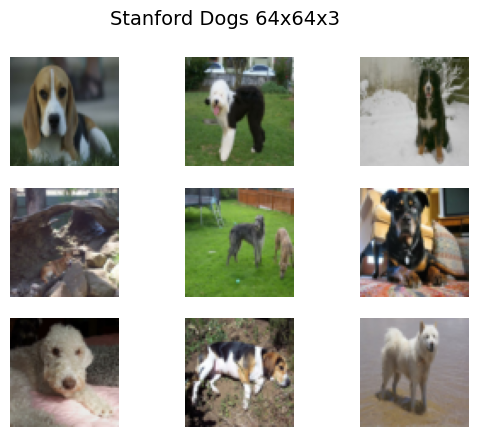

In [4]:
def grid_plot(images, epoch='', name='', n=3, save=False, scale=False):
    if scale:
        images = (images + 1) / 2.0
    for index in range(n * n):
        plt.subplot(n, n, 1 + index)
        plt.axis('off')
        plt.imshow(images[index])
    fig = plt.gcf()
    fig.suptitle(name + '  '+ str(epoch), fontsize=14)
    if save:
        filename = 'results/generated_plot_e%03d_f.png' % (epoch+1)
        plt.savefig(filename)
        plt.close()
    plt.show()

grid_plot(dataset[np.random.randint(0, 1000, 9)], name='Stanford Dogs 64x64x3', n=3)

## Possible Data Augmentation

In [ ]:
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Conv2DTranspose, Reshape

In [ ]:
# seem to be able to put into your model
# https://www.tensorflow.org/tutorials/images/data_augmentation

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])